# 03 — Modeling & Evaluation

Train and compare four models — Logistic Regression and Random Forest, each with `class_weight=None` and `'balanced'` — using a **per-repo chronological 80/20 split**, then evaluate.

**Why chronological, not random:** at deployment the webhook only sees issues newer than its training data, and label conventions drift over time. A random split leaks the future into the past and inflates the metrics. We sort each repo by `created_at` and take the last 20% as test.

**Why no SMOTE:** we report both class-weight settings to show the precision/recall trade reweighting buys, rather than fabricating synthetic issue text. Accuracy is shown but secondary — F1/recall on the positive class, ROC AUC, and the PR curve are the real evaluation.

In [1]:
# --- Layout-agnostic bootstrap (see notebook 01 for the full rationale) -------
# Works from the dev repo (src/, data/processed/) or the submission folder
# (Source_Code/, Dataset/); every step is a no-op in the dev layout.
import os, sys, pathlib, shutil, importlib

def _bootstrap():
    here = pathlib.Path.cwd()
    root = pkg = None
    for d in [here, *here.parents]:
        for name in ('src', 'Source_Code'):
            if (d / name / 'config.py').exists():
                root, pkg = d, d / name
                break
        if root:
            break
    if root is None:
        raise RuntimeError('Could not find src/ or Source_Code/ from ' + str(here))
    os.environ['GHIC_PROJECT_ROOT'] = str(root)
    if not (root / 'config.yaml').exists() and (pkg / 'config.yaml').exists():
        shutil.copy(pkg / 'config.yaml', root / 'config.yaml')
    proc = root / 'data' / 'processed'
    proc.mkdir(parents=True, exist_ok=True)
    for fname in ('combined.csv', 'releases.json'):
        if not (proc / fname).exists() and (root / 'Dataset' / fname).exists():
            shutil.copy(root / 'Dataset' / fname, proc / fname)
    sys.path.insert(0, str(root if pkg.name == 'src' else pkg.parent))
    if pkg.name != 'src' and 'src' not in sys.modules:
        sys.modules['src'] = importlib.import_module(pkg.name)
    return root

_bootstrap()
# ------------------------------------------------------------------------------
from ghic.config import get_config
from ghic import train, evaluate, utils
cfg = get_config(require_token=False)

# This notebook trains from labeled.csv. The submission ships combined.csv only,
# so build labeled.csv via the labeling rules when it is not already present.
if not (utils.DATA_PROCESSED / 'labeled.csv').exists():
    from ghic import label
    combined = utils.DATA_PROCESSED / 'combined.csv'
    assert combined.exists(), f'Missing {combined}. Run notebook 01 or provide the dataset.'
    issues = label._read_collected_csv(combined)
    kept, _ = label.label_dataset(issues, cfg)
    label._write_labeled_csv(utils.DATA_PROCESSED / 'labeled.csv', kept)
    print('Built labeled.csv from combined.csv')
assert (utils.DATA_PROCESSED / 'labeled.csv').exists(), 'labeled.csv still missing.'

2026-06-03 01:07:37,444 | INFO    | ghic.config | Loaded config: 3 repos, 7 bot logins, 7 bug labels, 12 non-actionable labels, 6 question labels (drop=True)


## Train all four models
Each model is a `Pipeline(preprocessor -> estimator)`; the preprocessor (TF-IDF + impute + scale) is fit on the training split only. Fitted pipelines are saved to `models/`, plots and `metrics.json` to `reports/`.

In [2]:
results = train.train_all(cfg, make_plots=True)

2026-06-03 01:07:37,460 | INFO    | ghic.train | Loading D:\mllab\github-issue-classifier\data\processed\labeled.csv


2026-06-03 01:07:37,890 | INFO    | ghic.train | Loaded release dates for 3 repos


2026-06-03 01:07:44,160 | INFO    | ghic.train | split facebook/react: 515 train / 129 test


2026-06-03 01:07:44,170 | INFO    | ghic.train | split microsoft/vscode: 3282 train / 820 test


2026-06-03 01:07:44,176 | INFO    | ghic.train | split tensorflow/tensorflow: 911 train / 228 test


...

2026-06-03 01:08:47,545 | INFO    | ghic.evaluate | wrote D:\mllab\github-issue-classifier\reports\roc_rf_balanced.png


2026-06-03 01:08:47,873 | INFO    | ghic.evaluate | wrote D:\mllab\github-issue-classifier\reports\pr_rf_balanced.png


2026-06-03 01:08:48,867 | INFO    | ghic.evaluate | wrote D:\mllab\github-issue-classifier\reports\importance_rf_balanced.png


2026-06-03 01:08:48,872 | INFO    | ghic.train | wrote D:\mllab\github-issue-classifier\reports\metrics.json


subset                            n    pos   prec    rec     f1    auc  prauc    acc
------------------------------------------------------------------------------------
logreg                         1177    261  0.718  0.575  0.638  0.869  0.722  0.856
logreg_balanced                1177    261  0.597  0.743  0.662  0.872  0.722  0.832
rf                             1177    261  0.787  0.625  0.697  0.895  0.769  0.879
rf_balanced                    1177    261  0.777  0.628  0.695  0.902  0.775  0.878


## Overall comparison

In [3]:
print(evaluate.metrics_table({name: r.overall for name, r in results.items()}))

subset                            n    pos   prec    rec     f1    auc  prauc    acc
------------------------------------------------------------------------------------
logreg                         1177    261  0.718  0.575  0.638  0.869  0.722  0.856
logreg_balanced                1177    261  0.597  0.743  0.662  0.872  0.722  0.832
rf                             1177    261  0.787  0.625  0.697  0.895  0.769  0.879
rf_balanced                    1177    261  0.777  0.628  0.695  0.902  0.775  0.878


## Per-repo breakdown (does the model generalize across codebases?)

In [4]:
for name, r in results.items():
    print(f'\n=== {name} ===')
    print(evaluate.metrics_table(r.per_repo))


=== logreg ===
subset                            n    pos   prec    rec     f1    auc  prauc    acc
------------------------------------------------------------------------------------
facebook/react                  129     23  0.654  0.739  0.694  0.881  0.711  0.884
microsoft/vscode                820    125  0.652  0.344  0.450  0.826  0.510  0.872
tensorflow/tensorflow           228    113  0.769  0.796  0.783  0.873  0.880  0.781

=== logreg_balanced ===
subset                            n    pos   prec    rec     f1    auc  prauc    acc
------------------------------------------------------------------------------------
facebook/react                  129     23  0.543  0.826  0.655  0.877  0.686  0.845
microsoft/vscode                820    125  0.529  0.584  0.555  0.832  0.519  0.857
tensorflow/tensorflow           228    113  0.671  0.903  0.770  0.871  0.877  0.732

=== rf ===
subset                            n    pos   prec    rec     f1    auc  prauc    acc
------------

## Plots
Confusion matrix, ROC, precision-recall, and feature influence are written to `reports/`. Display the balanced models inline.

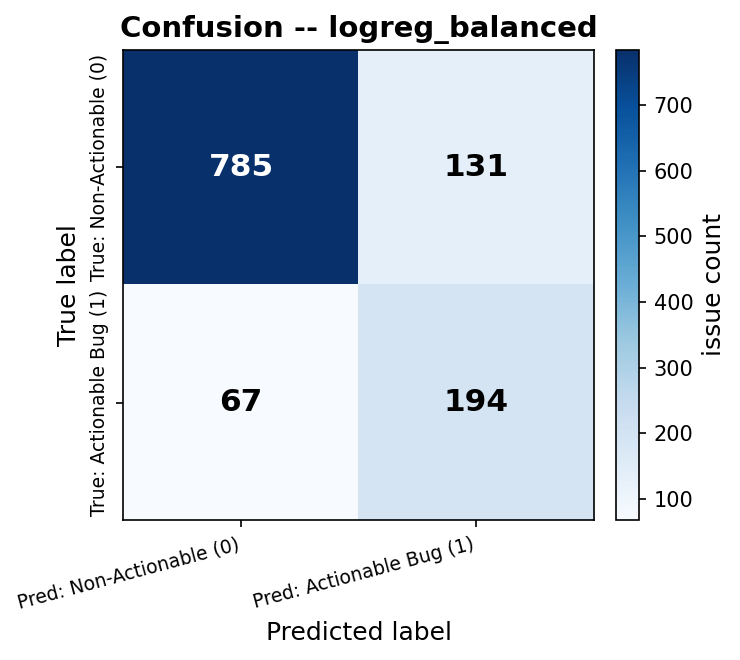

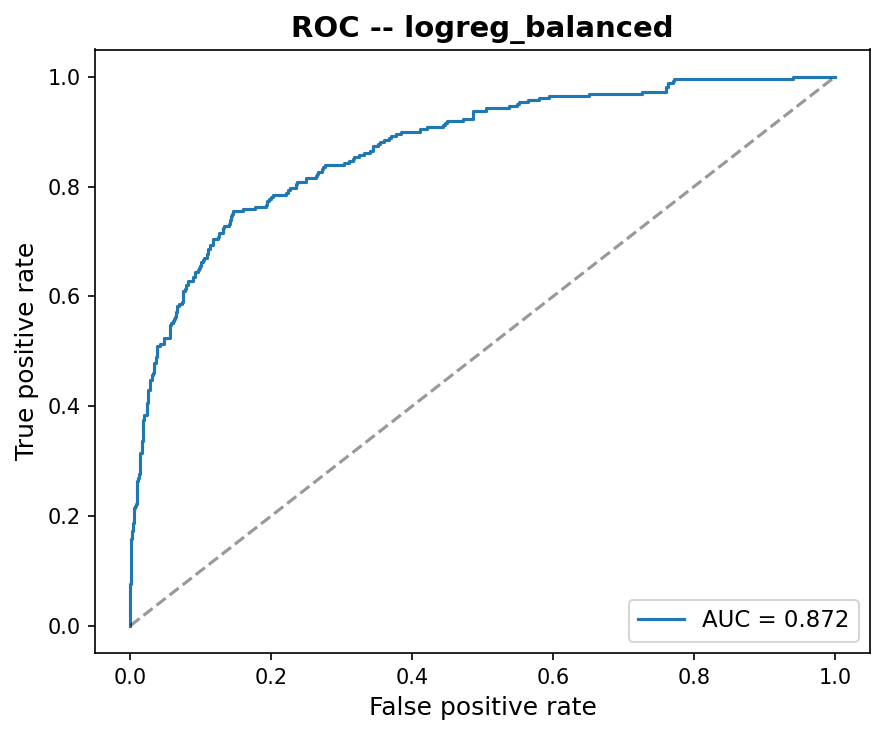

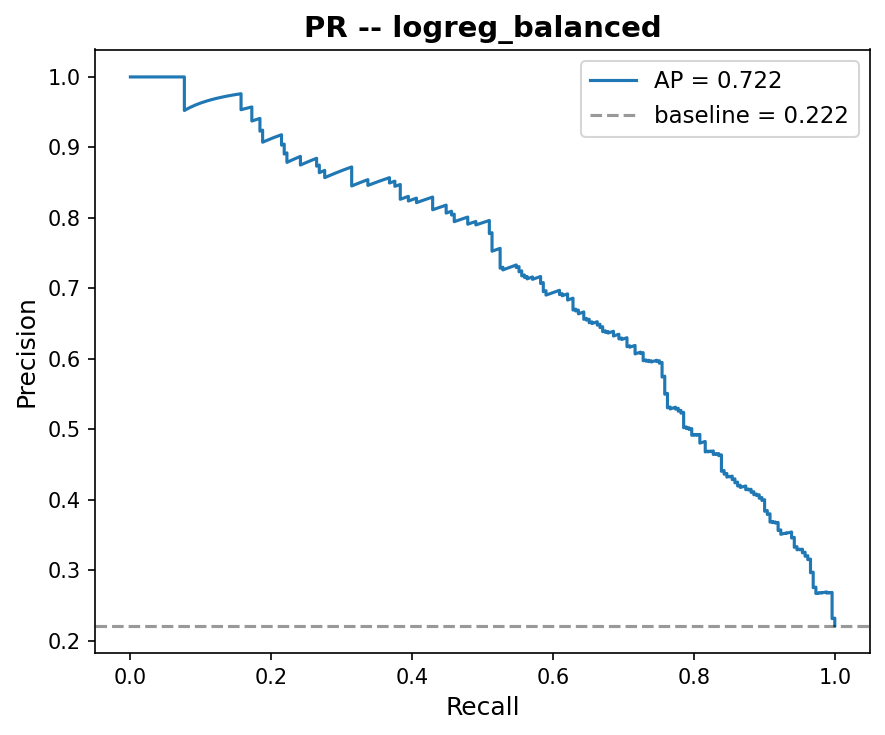

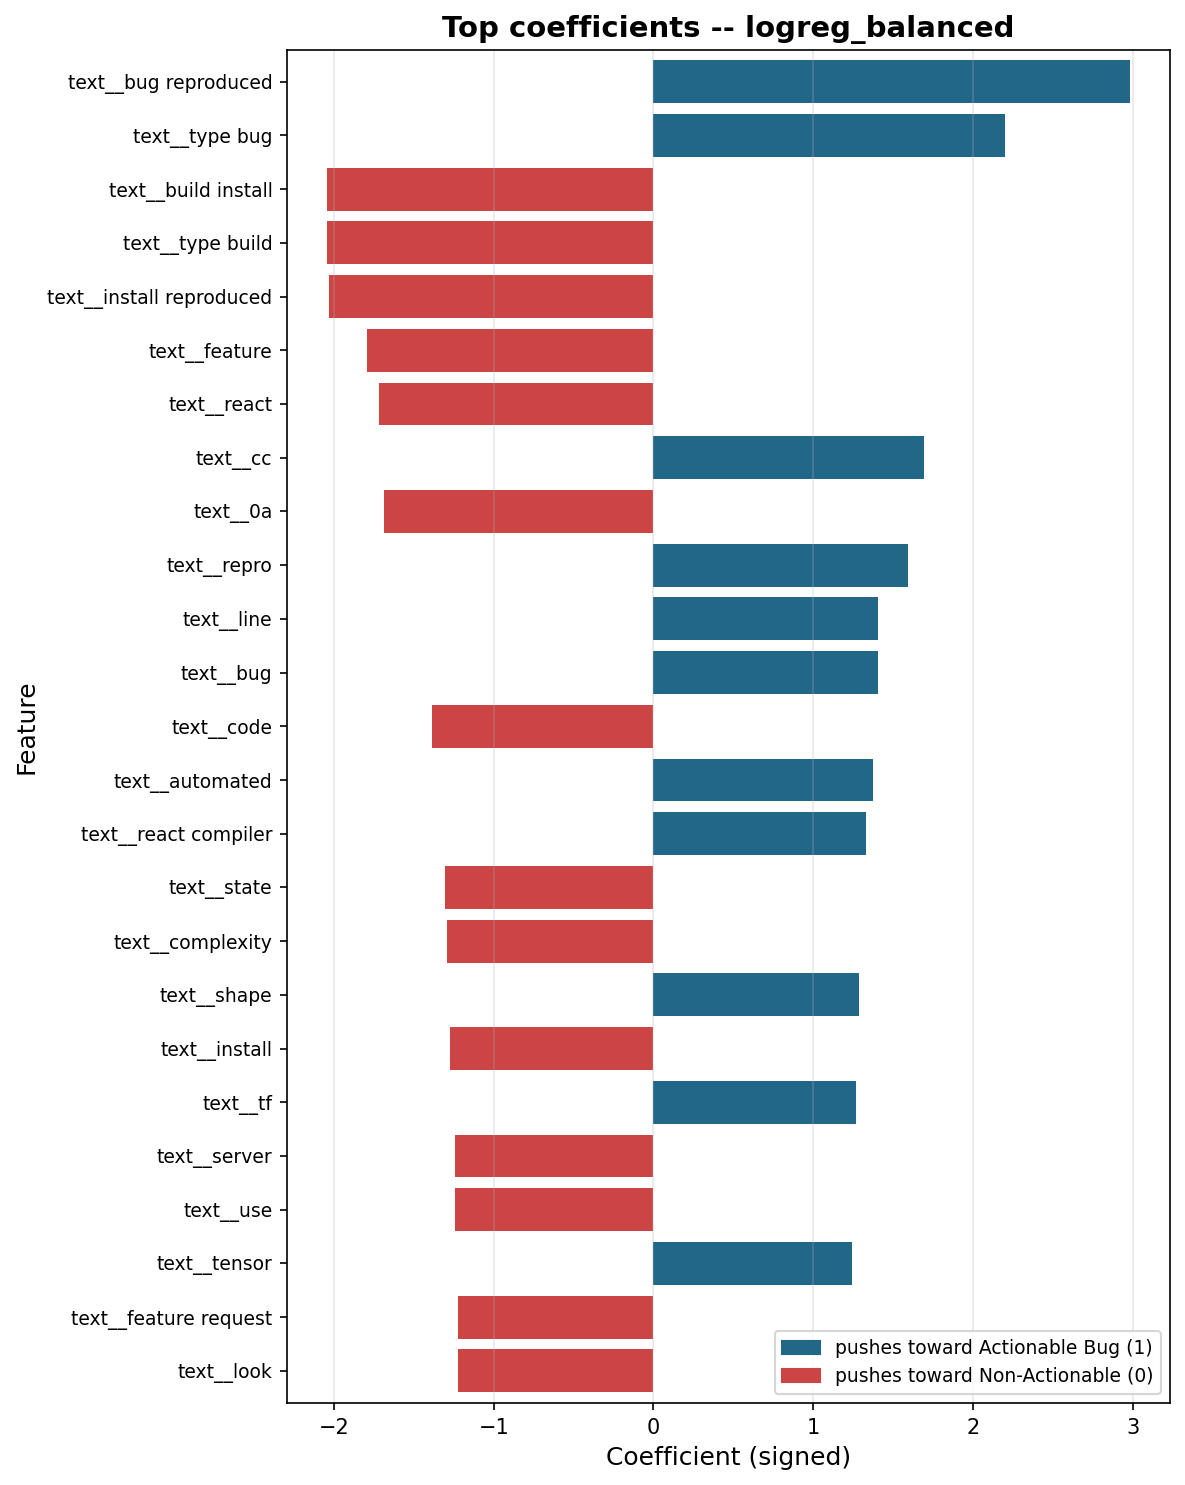

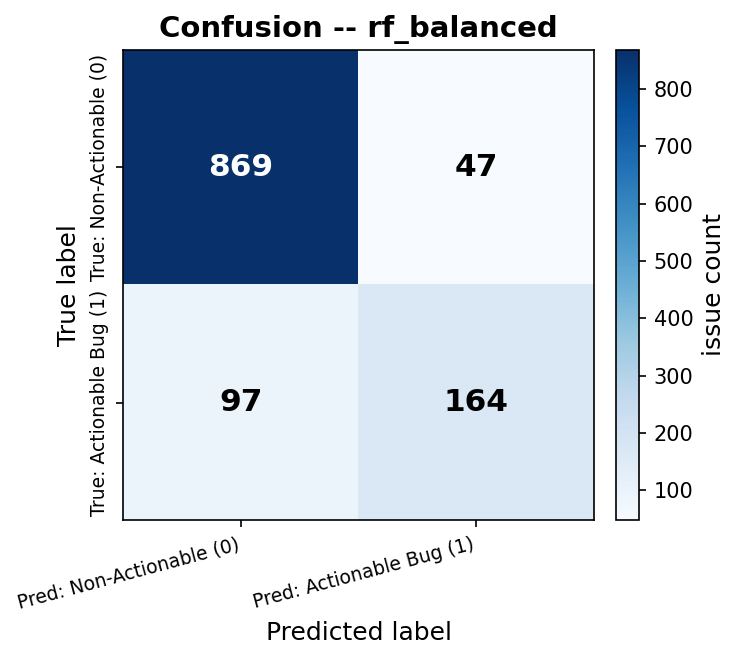

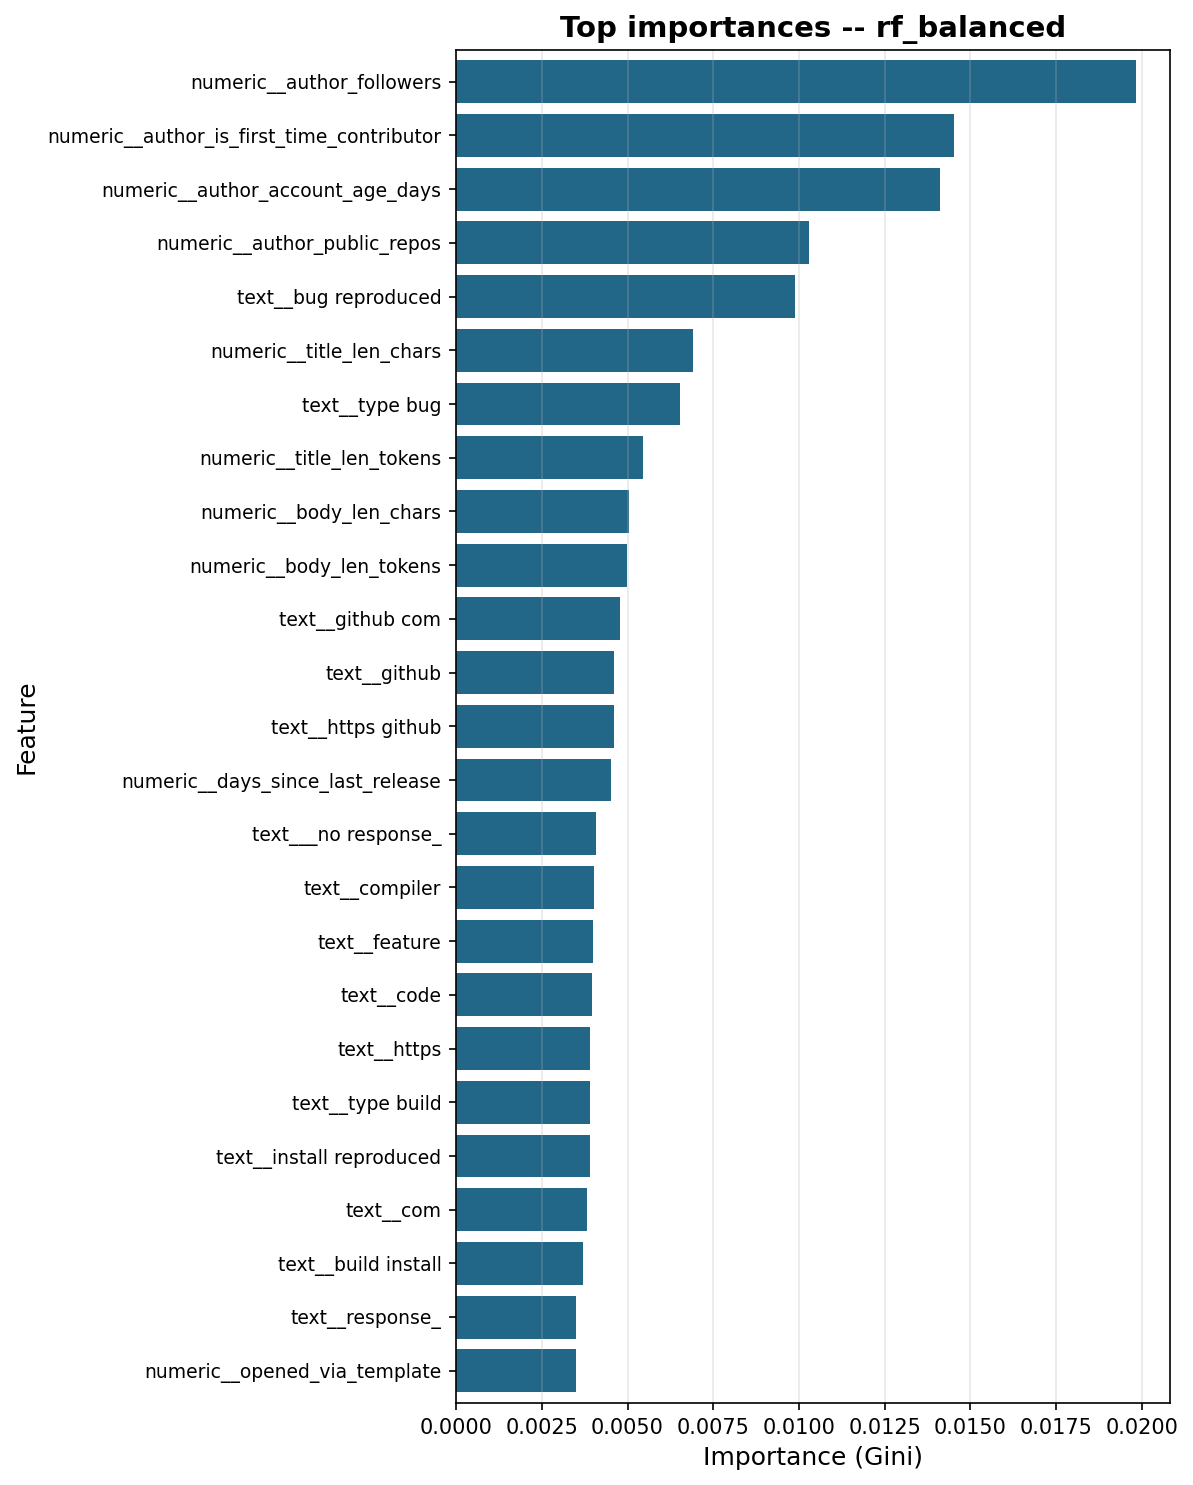

In [5]:
from IPython.display import Image, display
for f in ['cm_logreg_balanced.png', 'roc_logreg_balanced.png', 'pr_logreg_balanced.png',
          'coef_logreg_balanced.png', 'cm_rf_balanced.png', 'importance_rf_balanced.png']:
    p = evaluate.REPORTS_DIR / f
    if p.exists():
        display(Image(str(p)))

## Takeaways to defend
- LogReg coefficients give the *interpretable* story (which words/features push toward Actionable Bug); RF importances cross-check it non-linearly.
- Compare `*_balanced` vs plain: reweighting should raise recall on the minority Actionable-Bug class at some precision cost — quantify it from the table above.
- Watch the per-repo table: a model that only works on one repo is overfitting to that project's conventions, which matters for the GitHub App that must serve arbitrary repos.